In [ ]:
!pip install -q copernicusmarine xarray netCDF4
import torch
print(torch.__version__, torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 10.3 MB/s eta 0:00:00
2.11.0+cu130 True


In [ ]:
import copernicusmarine
copernicusmarine.login()

In [ ]:
import os
os.makedirs("data", exist_ok=True)

ID = "cmems_mod_glo_phy_my_0.083deg_P1D-m"
area = dict(minimum_longitude=80, maximum_longitude=90,
            minimum_latitude=10, maximum_latitude=20,
            start_datetime="2021-01-01", end_datetime="2021-06-30",
            output_directory="data")

# surface inputs: temperature, salinity, currents at the top level
copernicusmarine.subset(dataset_id=ID, variables=["thetao","so","uo","vo"],
    minimum_depth=0, maximum_depth=1, output_filename="surface.nc", **area)

# sea surface height has no depth axis, so it is requested separately
copernicusmarine.subset(dataset_id=ID, variables=["zos"],
    output_filename="zos.nc", **area)

# target: temperature from the surface down to 1000 m
copernicusmarine.subset(dataset_id=ID, variables=["thetao"],
    minimum_depth=0, maximum_depth=1000, output_filename="profile.nc", **area)

INFO - 2026-10-04T02:36:45Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-10-04T02:36:45Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-10-04T02:36:45Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-10-04T02:38:38Z - Total size of the download: 20.25 MB.
INFO:copernicusmarine:Total size of the download: 20.25 MB.
INFO - 2026-10-04T02:38:40Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-10-04T02:38:40Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-10-04T02:38:52Z - Total size of the download: 5.07 MB.
INFO:copernicusmarine:Total size of the download: 5.07 MB.
INFO - 2026-10-04T02:38:55Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-10-04T02:38:55Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"
WARNING - 2026-10-04T02:38:55Z - Some of your subset selection [0.0, 1000.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-10-04T02:43:54Z - Total size of the download: 177.02 MB.
INFO:copernicusmarine:Total size of the download: 177.02 MB.


ResponseSubset(file_path=PosixPath('data/profile.nc'), output_directory=PosixPath('data'), filename='profile.nc', file_size=177.02171564885498, data_transfer_size=23716.91871755725, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=80.0, maximum=90.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=10.0, maximum=20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2021-01-01T00:00:00+00:00', maximum='2021-06-30T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=902.3392944335938, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [ ]:
import xarray as xr
for f in ["surface", "zos", "profile"]:
    ds = xr.open_dataset(f"data/{f}.nc")
    print(f, dict(ds.sizes), list(ds.data_vars))

surface {'time': 181, 'depth': 1, 'latitude': 121, 'longitude': 121} ['thetao', 'so', 'uo', 'vo']
zos {'time': 181, 'latitude': 121, 'longitude': 121} ['zos']
profile {'time': 181, 'depth': 35, 'latitude': 121, 'longitude': 121} ['thetao']


In [ ]:
import numpy as np, xarray as xr

# 1/12 degree -> 0.25 degree: average each 3x3 block of grid cells
def coarsen(ds):
    return ds.coarsen(latitude=3, longitude=3, boundary="trim").mean()

sur = xr.open_dataset("data/surface.nc").isel(depth=0, drop=True)
zos = xr.open_dataset("data/zos.nc")
pro = xr.open_dataset("data/profile.nc")

# pick the model levels closest to the 15 standard depths
targets = [0,5,10,20,30,50,75,100,125,150,200,300,500,700,1000]
pro = pro.sel(depth=targets, method="nearest")
print("depths used (m):", np.round(pro.depth.values, 1))

sur, zos, pro = coarsen(sur), coarsen(zos), coarsen(pro)
assert (sur.time.values == pro.time.values).all() and (zos.time.values == pro.time.values).all()

# inputs: SST, SSS, SSH, current U, current V  -> (time, 5, lat, lon)
X = np.stack([sur.thetao.values, sur.so.values, zos.zos.values,
              sur.uo.values, sur.vo.values], axis=1)
# target: temperature at 15 depths -> (time, 15, lat, lon)
Y = pro.thetao.values

# train on Jan-Apr, test on May-Jun (the test period is never seen in training)
ntrain = int((pro.time.values < np.datetime64("2021-05-01")).sum())

# normalise using training-period statistics only
mu_x = np.nanmean(X[:ntrain], axis=(0,2,3), keepdims=True)
sd_x = np.nanstd(X[:ntrain],  axis=(0,2,3), keepdims=True)
mu_y = np.nanmean(Y[:ntrain], axis=(0,2,3), keepdims=True)
sd_y = np.nanstd(Y[:ntrain],  axis=(0,2,3), keepdims=True)

Xn = np.nan_to_num((X - mu_x) / sd_x).astype("float32")
Yn = np.nan_to_num((Y - mu_y) / sd_y).astype("float32")
M  = (~np.isnan(Y)).astype("float32")   # 1 = valid ocean point, 0 = land or below the seafloor

np.savez("data/prepared.npz", Xn=Xn, Yn=Yn, M=M, ntrain=ntrain,
         mu_y=mu_y, sd_y=sd_y, lat=pro.latitude.values, lon=pro.longitude.values)
print("X", Xn.shape, "Y", Yn.shape, "train days:", ntrain, "test days:", Xn.shape[0] - ntrain)

depths used (m): [5.000e-01 5.100e+00 9.600e+00 1.850e+01 2.940e+01 4.740e+01 7.790e+01
 9.230e+01 1.307e+02 1.559e+02 1.861e+02 3.181e+02 5.411e+02 6.436e+02
 9.023e+02]
X (181, 5, 40, 40) Y (181, 15, 40, 40) train days: 120 test days: 61


In [ ]:
import numpy as np, torch, torch.nn as nn

d = np.load("data/prepared.npz")
Xn, Yn, M = d["Xn"], d["Yn"], d["M"]
ntrain = int(d["ntrain"]); mu_y, sd_y = d["mu_y"], d["sd_y"]
dev = "cuda"
ntr = ntrain - 15                      # last 15 training days are used only to pick the best epoch
tt = lambda a: torch.tensor(a).to(dev)
Xtr, Ytr, Mtr = tt(Xn[:ntr]), tt(Yn[:ntr]), tt(M[:ntr])
Xva, Yva, Mva = tt(Xn[ntr:ntrain]), tt(Yn[ntr:ntrain]), tt(M[ntr:ntrain])
Xte = tt(Xn[ntrain:])

def block(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.GELU())

class OceanEmbedNet(nn.Module):
    def __init__(s):
        super().__init__()
        s.e1 = nn.Sequential(block(5, 32), block(32, 32))
        s.e2 = nn.Sequential(nn.MaxPool2d(2), block(32, 64), block(64, 64))
        s.e3 = nn.Sequential(nn.MaxPool2d(2), block(64, 128))      # latent embedding: 128 channels
        s.u2 = nn.ConvTranspose2d(128, 64, 2, 2); s.d2 = block(128, 64)
        s.u1 = nn.ConvTranspose2d(64, 32, 2, 2);  s.d1 = block(64, 32)
        s.head = nn.Conv2d(32, 15, 1)                              # 15 depth levels
    def forward(s, x):
        a = s.e1(x); b = s.e2(a); z = s.e3(b)
        y = s.d2(torch.cat([s.u2(z), b], 1))
        y = s.d1(torch.cat([s.u1(y), a], 1))
        return s.head(y)

def loss_fn(p, y, m):
    mse = ((p - y) ** 2 * m).sum() / m.sum()
    dp, dy = p[:, 1:] - p[:, :-1], y[:, 1:] - y[:, :-1]            # vertical consistency term
    mv = m[:, 1:] * m[:, :-1]
    return mse + 0.5 * (((dp - dy) ** 2 * mv).sum() / mv.sum())

model = OceanEmbedNet().to(dev)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
best, best_val = None, 1e9
for ep in range(80):
    model.train()
    perm = torch.randperm(ntr, device=dev)
    for i in range(0, ntr, 8):
        idx = perm[i:i + 8]
        opt.zero_grad()
        loss_fn(model(Xtr[idx]), Ytr[idx], Mtr[idx]).backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        v = loss_fn(model(Xva), Yva, Mva).item()
    if v < best_val:
        best_val, best = v, {k: t.clone() for k, t in model.state_dict().items()}
    if ep % 10 == 0:
        print(f"epoch {ep:2d}  val loss {v:.4f}")
print("best val loss:", round(best_val, 4))

# ---- evaluation on the unseen May-June test days ----
model.load_state_dict(best); model.eval()
with torch.no_grad():
    P = model(Xte).cpu().numpy()
den = lambda a: a * sd_y + mu_y
Pt, Tt, Mt = den(P), den(Yn[ntrain:]), M[ntrain:]
Ytr_d, Mall = den(Yn[:ntrain]), M[:ntrain]
clim = (Ytr_d * Mall).sum(0, keepdims=True) / np.maximum(Mall.sum(0, keepdims=True), 1)   # baseline

depths = [0.5,5.1,9.6,18.5,29.4,47.4,77.9,92.3,130.7,155.9,186.1,318.1,541.1,643.6,902.3]
print("\ndepth(m)  RMSE   bias   baseline_RMSE  anomaly_corr")
for k in range(15):
    m = Mt[:, k] > 0
    p, t = Pt[:, k][m], Tt[:, k][m]
    c = np.broadcast_to(clim[:, k], Pt[:, k].shape)[m]
    rmse = np.sqrt(np.mean((p - t) ** 2)); bias = np.mean(p - t)
    rb = np.sqrt(np.mean((c - t) ** 2))
    r = np.corrcoef(p - c, t - c)[0, 1]
    print(f"{depths[k]:7.1f}  {rmse:5.2f}  {bias:6.2f}  {rb:10.2f}  {r:10.2f}")

torch.save(best, "data/model.pt")

epoch  0  val loss 0.9993
epoch 10  val loss 0.2435
epoch 20  val loss 0.2113
epoch 30  val loss 0.2222
epoch 40  val loss 0.1900
epoch 50  val loss 0.1880
epoch 60  val loss 0.1864
epoch 70  val loss 0.1957
best val loss: 0.1805

depth(m)  RMSE   bias   baseline_RMSE  anomaly_corr
    0.5   0.50   -0.16        2.29        0.75
    5.1   0.58   -0.37        2.33        0.75
    9.6   0.58   -0.38        2.29        0.75
   18.5   0.60   -0.42        2.18        0.72
   29.4   0.75   -0.57        1.95        0.53
   47.4   0.74   -0.45        1.25        0.42
   77.9   0.65    0.17        1.21        0.85
   92.3   0.87    0.35        1.66        0.88
  130.7   0.98    0.47        1.91        0.90
  155.9   0.83    0.38        1.64        0.89
  186.1   0.64    0.27        1.25        0.89
  318.1   0.29    0.10        0.41        0.70
  541.1   0.19    0.04        0.27        0.56
  643.6   0.19    0.02        0.25        0.53
  902.3   0.19    0.00        0.22        0.53


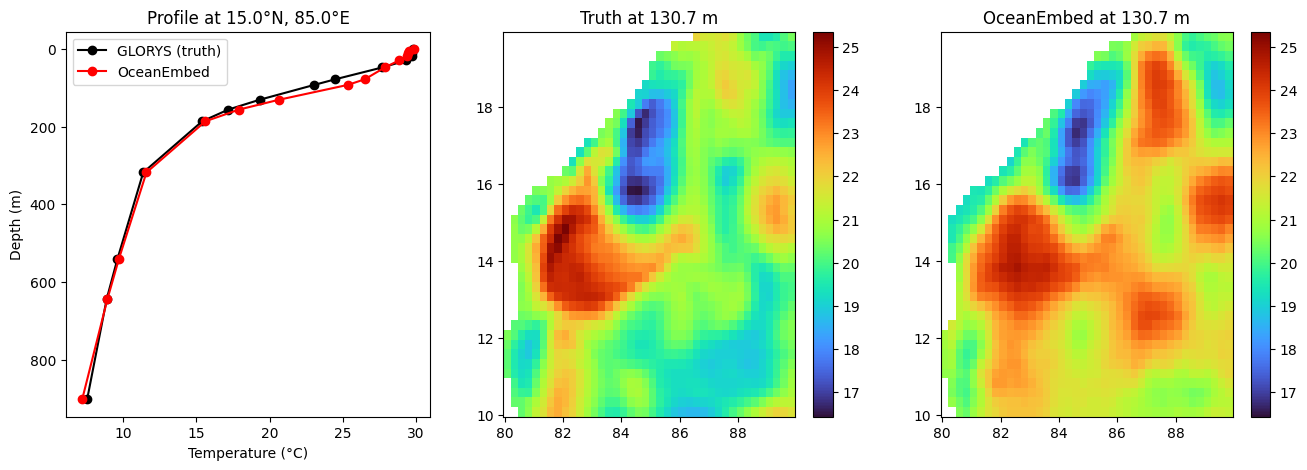

In [ ]:
import matplotlib.pyplot as plt
lat, lon = d["lat"], d["lon"]

def show(day=30, la=15.0, lo=85.0, k=8):
    i, j = np.abs(lat-la).argmin(), np.abs(lon-lo).argmin()
    T, P = np.where(Mt[day,k]>0, Tt[day,k], np.nan), np.where(Mt[day,k]>0, Pt[day,k], np.nan)
    vmin, vmax = np.nanmin(T), np.nanmax(T)
    fig, ax = plt.subplots(1, 3, figsize=(16,5))
    ax[0].plot(Tt[day,:,i,j], depths, 'k-o', label='GLORYS (truth)')
    ax[0].plot(Pt[day,:,i,j], depths, 'r-o', label='OceanEmbed')
    ax[0].invert_yaxis(); ax[0].set_xlabel('Temperature (°C)'); ax[0].set_ylabel('Depth (m)')
    ax[0].set_title(f'Profile at {la}°N, {lo}°E'); ax[0].legend()
    for a, f, t in [(ax[1], T, 'Truth'), (ax[2], P, 'OceanEmbed')]:
        im = a.pcolormesh(lon, lat, f, vmin=vmin, vmax=vmax, cmap='turbo')
        a.set_title(f'{t} at {depths[k]} m'); plt.colorbar(im, ax=a)
    plt.show()

show(day=60, la=15.0, lo=85.0, k=8)